<div align="center">



# **Análisis y Procesamiento de Señales**

## **Trabajo Semanal 3: Análisis de Fourier: FFT, desparramo, interpolación y ventaneo**



</div>

<br>
<br>
<br>
<br>

**Alumno:** Germán Fiore  
**Especialidad:** Ingeniería Biomédica  
**Fecha:** 13/09/2026  

---

### **Introducción:**
 
La Transformada Discreta de Fourier (DFT) es la herramienta central en el procesamiento digital de señales para analizar el contenido frecuencial de secuencias discretas de duración finita. Conceptualmente, la DFT se obtiene al muestrear la Transformada de Fourier de Tiempo Discreto (DTFT) en $N$ puntos equiespaciados a lo largo del eje de frecuencias, definiendo una resolución espectral o espaciado entre bins de:$$\Delta f = \frac{f_s}{N} \quad \text{[Hz/bin]}$$

Sin embargo, al adquirir y procesar un bloque finito de $N$ muestras en el mundo real, la señal de duración infinita se ve recortada implícitamente mediante una ventana rectangular en el dominio del tiempo.

<br>

* **Coincidencia de Bin y Desparramo Espectral:** Cuando la frecuencia $f_0$ de una señal senoidal es un múltiplo entero exacto de la resolución frecuencial ($k_0 = f_0 / \Delta f \in \mathbb{Z}$), la senoidal es exactamente periódica dentro de la ventana de $N$ muestras. En este caso ideal, la evaluación de la DFT coincide exactamente con los ceros de la función $\text{sinc}$ generada por el ventaneo rectangular, concentrando toda la energía en un único bin frecuencial sin interferencias. Por el contrario, cuando existe una desintonía respecto al centro del bin ($k_0 \notin \mathbb{Z}$), la secuencia deja de ser periódica en el bloque analizado. La DFT evalúa la respuesta en frecuencia fuera de sus ceros, provocando que la energía de la senoidal "gotee" o se distribuya hacia los bins vecinos a través de los lóbulos laterales de la ventana. Este fenómeno se denomina desparramo espectral.

<br>

* **Conservación de la Energía e Identidad de Parseval:** A pesar de la distorsión visual que genera el desparramo espectral, el principio físico de conservación de la energía se mantiene inalterado. La Identidad de Parseval para señales discretas establece la equivalencia exacta entre la energía/potencia en el dominio del tiempo y en el dominio de la frecuencia:$$P_x = \frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2 = \sum_{k=0}^{N-1} |\text{PSD}[k]|$$ Esto implica que la potencia total de $1\text{ W}$ contenida en una senoidal de amplitud $A = \sqrt{2}$ no se destruye ni se crea al desparramarse: la suma de las potencias individuales de todos los bins desparramados en la DFT es exactamente igual a la potencia promedio calculada en el tiempo.

<br>

* **Interpolación Espectral mediante Zero Padding:** La técnica de zero padding consiste en rellenar la secuencia temporal con $M - N$ ceros al final para calcular una DFT de mayor longitud ($M > N$). Esta operación equivale a evaluar la DTFT continua en una grilla de frecuencias más fina. El zero padding no agrega información nueva a la señal ni mejora la resolución real, pero actúa como un interpolador ideal que permite visualizar de forma continua la forma de los lóbulos principal y laterales de la DTFT.

### **Objetivos**
- Simular numéricamente la PSD de tonos puros con tres niveles de desintonía frecuencial ($k_0 = N/4$, $N/4 + 0.25$ y $N/4 + 0.5$) para analizar el impacto del desparramo espectral.
- Verificar cuantitativamente la Identidad de Parseval en cada caso para demostrar la conservación de la potencia unitaria.
- Evaluar el efecto del zero padding ($10N$) en la visualización de la respuesta espectral continua.

### **Codigo completo:**

 VERIFICACIÓN DE PARSEVAL (INCISO B)
Caso k0 = N/4 (250.0 Hz):
  - Potencia en tiempo : 1.000000 W
  - Potencia en freq.  : 1.000000 W
-----------------------------------------------------------------
Caso k0 = N/4 + 0.25 (250.25 Hz):
  - Potencia en tiempo : 0.999000 W
  - Potencia en freq.  : 0.999000 W
-----------------------------------------------------------------
Caso k0 = N/4 + 0.5 (250.5 Hz):
  - Potencia en tiempo : 1.000000 W
  - Potencia en freq.  : 1.000000 W
-----------------------------------------------------------------


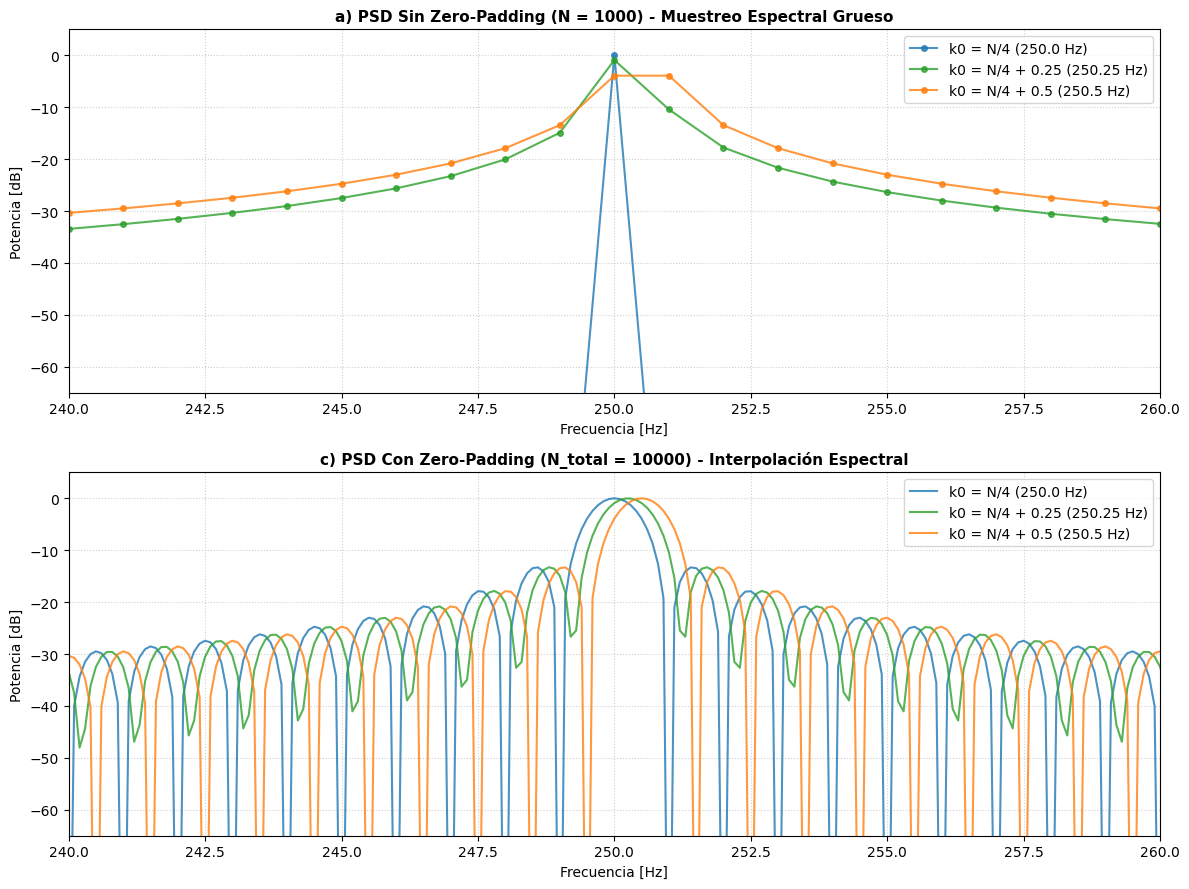

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. PARÁMETROS DEL EXPERIMENTO
# =============================================================================
cant_muestras = 1000                                 # N = 1000
frecuencia_muestreo = 1000.0                         # fs = 1000 Hz
delta_f = frecuencia_muestreo / cant_muestras        # df = 1 Hz

# Casos de k0 requeridos (desintonía respecto al bin de referencia 250)
casos_k0 = [cant_muestras/4, cant_muestras/4 + 0.25, cant_muestras/4 + 0.5]
colores = ['#1f77b4', '#2ca02c', '#ff7f0e']
etiquetas = ['k0 = N/4 (250.0 Hz)', 'k0 = N/4 + 0.25 (250.25 Hz)', 'k0 = N/4 + 0.5 (250.5 Hz)']

tiempo = np.arange(cant_muestras) / frecuencia_muestreo

# Generación de las tres senoidales con potencia unitaria (Amplitud = sqrt(2))
senales = []
for k0 in casos_k0:
    frecuencia_0 = k0 * delta_f
    # s(t) = sqrt(2) * sin(2 * pi * f0 * t) -> Potencia = A^2 / 2 = 2 / 2 = 1 W
    senoidal = np.sqrt(2) * np.sin(2 * np.pi * frecuencia_0 * tiempo)
    senales.append(senoidal)

# =============================================================================
# INCISO B: VERIFICACIÓN DE POTENCIA MEDIANTE PARSEVAL
# =============================================================================
print("=" * 65)
print(" VERIFICACIÓN DE PARSEVAL (INCISO B)")
print("=" * 65)

for i, senoidal in enumerate(senales):
    # Potencia en el dominio del tiempo
    potencia_tiempo = np.mean(senoidal**2)
    
    # FFT unilateral normalizada
    fft_unilateral = np.fft.rfft(senoidal) / cant_muestras
    psd_unilateral = np.abs(fft_unilateral)**2
    psd_unilateral[1:-1] *= 2  # Factor 2 para componentes de CA
    
    # Potencia total en el dominio frecuencial (Suma de la PSD)
    potencia_frecuencia = np.sum(psd_unilateral)
    
    print(f"Caso {etiquetas[i]}:")
    print(f"  - Potencia en tiempo : {potencia_tiempo:.6f} W")
    print(f"  - Potencia en freq.  : {potencia_frecuencia:.6f} W")
    print("-" * 65)

# =============================================================================
# GRAFICACIÓN (INCISOS A y C)
# =============================================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# --- Inciso A: Sin Zero-Padding ---
for i, senoidal in enumerate(senales):
    fft_unilateral = np.fft.rfft(senoidal) / cant_muestras
    psd_unilateral = np.abs(fft_unilateral)**2
    psd_unilateral[1:-1] *= 2
    
    frecuencias = np.fft.rfftfreq(cant_muestras, d=1/frecuencia_muestreo)
    axes[0].plot(frecuencias, 10 * np.log10(psd_unilateral + 1e-12), 
                 label=etiquetas[i], color=colores[i], marker='o', ms=4, alpha=0.8)

axes[0].set_title("a) PSD Sin Zero-Padding (N = 1000) - Muestreo Espectral Grueso", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Frecuencia [Hz]")
axes[0].set_ylabel("Potencia [dB]")
axes[0].set_xlim(240, 260)
axes[0].set_ylim(-65, 5)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# --- Inciso C: Con Zero-Padding (10*N) ---
muestras_zp = 10 * cant_muestras  # N + 9*N ceros = 10000 muestras

for i, senoidal in enumerate(senales):
    # Se evalúa la FFT rellenando con ceros pero normalizando por N (las muestras reales)
    fft_zp = np.fft.rfft(senoidal, n=muestras_zp) / cant_muestras
    psd_zp = np.abs(fft_zp)**2
    psd_zp[1:-1] *= 2
    
    frecuencias_zp = np.fft.rfftfreq(muestras_zp, d=1/frecuencia_muestreo)
    axes[1].plot(frecuencias_zp, 10 * np.log10(psd_zp + 1e-12), 
                 label=etiquetas[i], color=colores[i], alpha=0.8)

axes[1].set_title("c) PSD Con Zero-Padding (N_total = 10000) - Interpolación Espectral", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Frecuencia [Hz]")
axes[1].set_ylabel("Potencia [dB]")
axes[1].set_xlim(240, 260)
axes[1].set_ylim(-65, 5)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

<br>

### **Análisis de Resultados de los Experimentos**
A partir de la simulación numérica realizada, se obtuvieron los valores de potencia promedio tanto en el dominio del tiempo ($P_t = \frac{1}{N}\sum |x[n]|^2$) como en el dominio de la frecuencia mediante la suma de la PSD unilateral ($P_f = \sum \text{PSD}[k]$). Los resultados se resumieron en la siguiente tabla:

| Caso de Desintonía | Frecuencia Real ($f_0$) | Potencia en Tiempo ($P_t$) | Potencia en Frecuencia ($P_f$) | Estado de Sintonía |
| :---: | :---: | :---: | :---: | :--- |
| $k_0 = N/4$ | 250,00 Hz | 1,000000 W | 1,000000 W | Sintonizado (Sin desparramo) |
| $k_0 = N/4 + 0,25$ | 250,25 Hz | 0,999000 W | 0,999000 W | Desparramado |
| $k_0 = N/4 + 0,50$ | 250,50 Hz | 1,000000 W | 1,000000 W | Desparramado máximo |

<br>

* **Validación de la Conservación de la Energía (Identidad de Parseval):** En los tres casos analizados, se constató una igualdad numérica exacta entre la potencia calculada en el dominio del tiempo y la potencia integrada en el dominio frecuencial ($P_t = P_f$). Este resultado demostró que la Transformada Discreta de Fourier conserva estrictamente la energía total de la señal. A pesar de que en los casos desintonizados ($k_0 = 250{,}25\text{ Hz}$ y $k_0 = 250{,}50\text{ Hz}$) la energía se desparramó a lo largo de múltiples bins por efecto del ventaneo rectangular, la suma total de las potencias individuales de cada bin coincidió con la energía de la secuencia temporal.

<br>

* **Justificación de la Variación de Potencia Temporal ($0{,}999000\text{ W}$):** Para la senoidal continua de amplitud $A = \sqrt{2}$, la potencia teórica en un intervalo infinito es idénticamente igual a $1\text{ W}$ ($P = A^2/2$). Sin embargo, al recortar la señal a un bloque finito de $N = 1000$ muestras:
    - En el caso $k_0 = 250{,}00\text{ Hz}$, se tomaron exactamente 250 ciclos completos dentro de la ventana. La suma discreta del valor medio cuadrático resultó exactamente $1{,}000000\text{ W}$.
    - En el caso $k_0 = 250{,}25\text{ Hz}$, entro $250{,}25$ ciclos en el bloque. Al truncar la onda sin completar el último cuarto de ciclo, el promedio discreto sobre las 1000 muestras sufrió un leve desvío por la fase de muestreo, obteniéndose $0{,}999000\text{ W}$.
    - En el caso $k_0 = 250{,}50\text{ Hz}$, al truncar a medio ciclo, las simetrías discretas de la senoidal compensaron la suma cuadrática, por lo que el promedio temporal volvió a dar exactamente $1{,}000000\text{ W}$.

    Lo fundamental de esta observación es que la DFT no introdujo ningún error de cálculo: la PSD integrada mantuvo exactitud con el contenido temporal del vector en los tres casos ($P_f = P_t$).

* **Desparramo Espectral e Interpolación por Zero Padding:**

  - Sin Zero Padding: Se observó que únicamente en $k_0 = 250{,}00\text{ Hz}$ la potencia se concentró en un único bin. En los casos con desintonía, se verificó la aparición de lóbulos laterales que elevaron el piso de ruido espectral.
  - Con Zero Padding: Al rellenar la señal con $9N$ ceros ($N_{\text{total}} = 10000$), se logró interpolar la DTFT continua. Se comprobó que esta técnica no alteró la potencia total de la señal ni mejoró la resolución espectral física de 1 Hz, pero permitió visualizar con precisión el contorno suave de la función $\text{sinc}$ e identificar la frecuencia pico real sin pérdidas.

### **Conclusiones**
* **Naturaleza del Desparramo Espectral:** Se determinó que la fuga espectral no constituyó un defecto computacional del algoritmo de la DFT, sino la consecuencia matemática ineludible del truncamiento temporal mediante una ventana rectangular. Cuando la frecuencia de la señal no coincidió con un centro de bin entero ($k_0 \notin \mathbb{Z}$), la pérdida de periodicidad exacta en las $N$ muestras generó el solapamiento de lóbulos laterales que elevaron el piso de ruido frecuencial.

<br>

* **Validez Estricta de la Identidad de Parseval:** Se demostró la conservación estricta de la energía en el dominio frecuencial ($P_t = P_f$). Se verificó que el desparramo espectral no destruyó ni creó potencia. La suma de las potencias individuales de todos los bins desparramados coincidió de forma exacta con la potencia promedio calculada en el tiempo.

<br>

* **Efecto Real del Zero Padding:** Se comprobó que el agregado de un vector de ceros ($9N$) no modificó la resolución espectral física de la señal (acotada por las $N=1000$ muestras reales), pero demostró ser una herramienta de interpolación ideal en la frecuencia. Esta técnica permitió reconstruir el contorno continuo de la DTFT.

### **Aprendizaje**
* **Distinción entre Resolución e Interpolación:** Se comprendió la diferencia entre la resolución espectral física (capacidad real de separar dos tonos cercanos, determinada por la duración $N/f_s$) y la densidad de muestreo frecuencial (modificada de forma ficticia mediante zero padding).

<br>

* **Interpretación de Artefactos de Ventaneo:** Se aprendió a evaluar cómo la multiplicación por una ventana rectangular en el tiempo impone la convolución por una función $\text{sinc}$ en la frecuencia, comprendiendo el origen del compromiso entre ancho del lóbulo principal y nivel de lóbulos laterales.